In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [111]:
dir1 = "MixedPlay/50reps_100eps_100epL_02jan2026_IQL_vs_IQL"
dir2 = "MixedPlay/50reps_100eps_100epL_03jan2026_IQL_vs_IQL"
df_1 = pd.read_csv(f"{dir1}/eval_returns.csv", index_col=0)
df_2 = pd.read_csv(f"{dir2}/eval_returns.csv", index_col=0)

df_1.head()

,agent_1_returns,agent_2_returns
repetition,,
1,"[0.08, 0.08, 0.0, 0.4, 0.08, 0.4, 0.08, 0.08, ...","[0.12, 0.12, 0.2, 0.6, 0.12, 0.6, 0.12, 0.12, ..."
2,"[0.4, 0.4, 0.08, 0.32, 0.08, 0.52, 0.4, 0.4, 0...","[0.6, 0.6, 0.12, 0.6799999999999999, 0.12, 0.4..."
3,"[0.52, 0.52, 0.52, 0.32, 0.52, 0.52, 0.52, 0.5...","[0.48, 0.48, 0.48, 0.6799999999999999, 0.48, 0..."
4,"[0.52, 0.52, 0.52, 0.52, 0.52, 0.52, 0.52, 0.5...","[0.48, 0.48, 0.48, 0.48, 0.48, 0.48, 0.48, 0.4..."
5,"[0.2, 0.2, 0.2, 0.0, 0.2, 0.2, 0.2, 0.2, 0.2, ...","[0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [112]:
def _to_list(l):
    l = l[1:-1].split(", ")
    return [float(elm) for elm in l]
def _mean(l):
    l = _to_list(l)
    return np.mean(l)
def _std(l):
    l = _to_list(l)
    return np.std(l)

df_1["agent_1_mean"] = df_1["agent_1_returns"].apply(_mean)
df_1["agent_2_mean"] = df_1["agent_2_returns"].apply(_mean)
df_1["agent_1_std"] = df_1["agent_1_returns"].apply(_std)
df_1["agent_2_std"] = df_1["agent_2_returns"].apply(_std)

df_2["agent_1_mean"] = df_2["agent_1_returns"].apply(_mean)
df_2["agent_2_mean"] = df_2["agent_2_returns"].apply(_mean)
df_2["agent_1_std"] = df_2["agent_1_returns"].apply(_std)
df_2["agent_2_std"] = df_2["agent_2_returns"].apply(_std)


df_1["agent_1_mean"].head()

repetition
1    0.137333
2    0.282667
3    0.493333
4    0.513333
5    0.222667
Name: agent_1_mean, dtype: float64

In [113]:
def bootstrap_distribution(data, n_bootstrap=10000, confidence_level=0.95):

    data = np.array(data)
    n = len(data)
    
    bootstrap_means = np.array([
        np.mean(np.random.choice(data, size=n, replace=True))
        for _ in range(n_bootstrap)
    ])
    
    #CI
    alpha = 1 - confidence_level
    ci_lower = np.percentile(bootstrap_means, 100 * alpha / 2)
    ci_upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))
    
    # Bootstrap standard error
    se = np.std(bootstrap_means)
    
    return bootstrap_means, ci_lower, ci_upper, se

# Run bootstrap on agent_1_mean
def hist_result(agent_statistics):
    bootstrap_means, ci_lower, ci_upper, se = bootstrap_distribution(agent_statistics)

    # Summary statistics
    observed_mean = np.mean(agent_statistics)
    print(f"Observed mean: {observed_mean:.4f}")
    print(f"Bootstrap SE: {se:.4f}")
    print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

    # Plot bootstrap distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histograms
    axes[0].hist(bootstrap_means, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    axes[0].axvline(observed_mean, color='red', linestyle='--', linewidth=2, label=f'Observed mean: {observed_mean:.3f}')
    axes[0].axvline(ci_lower, color='orange', linestyle=':', linewidth=2, label=f'95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')
    axes[0].axvline(ci_upper, color='orange', linestyle=':', linewidth=2)
    axes[0].set_xlabel('Bootstrap Mean')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Bootstrap Distribution of Agent 1 Mean Return')
    axes[0].legend()

    #comparison
    axes[1].hist(agent_statistics, bins=20, density=True, alpha=0.7, color='forestgreen', edgecolor='white')
    axes[1].axvline(observed_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {observed_mean:.3f}')
    axes[1].set_xlabel('Mean Return per Repetition')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Original Distribution of Agent 1 Mean Returns')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Observed mean: 0.3392
Bootstrap SE: 0.0161
95% CI: [0.3072, 0.3710]


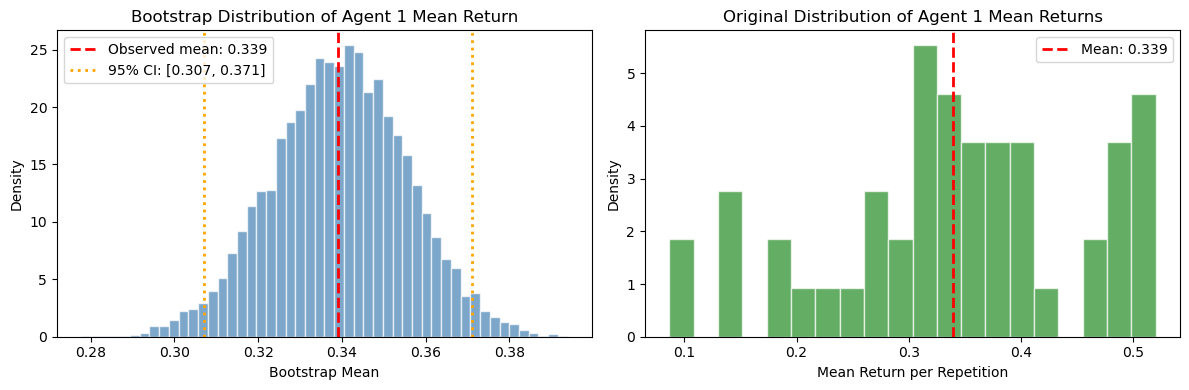

In [114]:
hist_result(df_1["agent_1_mean"].values)

Observed mean: 0.4910
Bootstrap SE: 0.0206
95% CI: [0.4496, 0.5303]


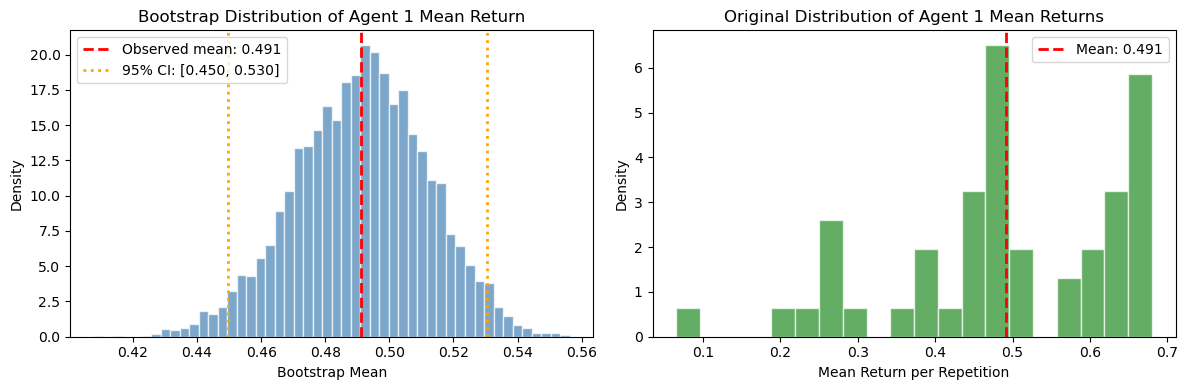

In [ ]:
hist_result(df_2["agent_1_mean"].values)

0.6799999999999999

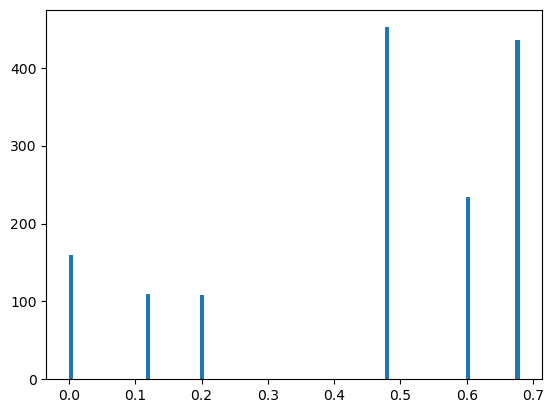

In [ ]:
a1_returns = [_to_list(l) for l in df_1["agent_1_returns"].values]
all_a1_returns = np.asarray(a1_returns).flatten()
plt.hist(all_a1_returns, bins=100)

Observed mean: 0.4591
Bootstrap SE: 0.0059
95% CI: [0.4474, 0.4707]


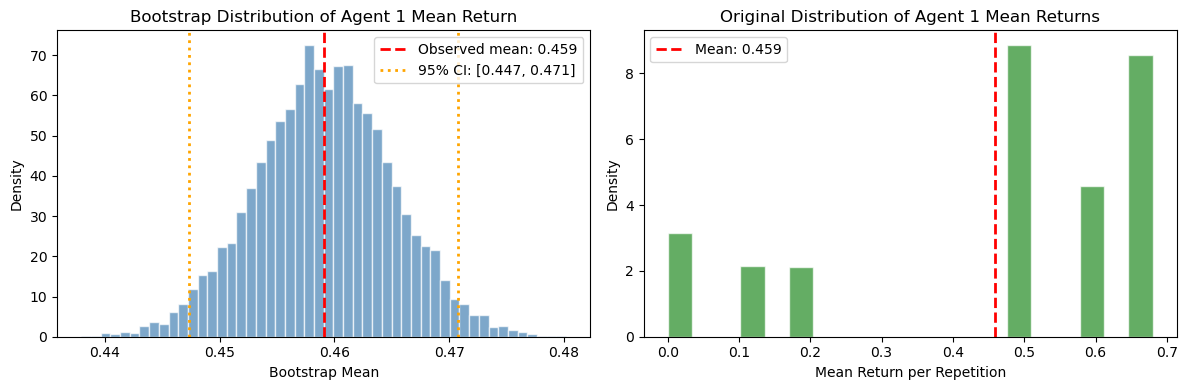

In [107]:
hist_result(all_a1_returns)

In [ ]:
hist_result(df_1["agent_2_mean"])

In [117]:
# Welch's t-test: two-sided difference test comparing agent_1_mean vs agent_2_mean

# Extract the mean returns for each agent
agent_1_means = df_1["agent_1_mean"].values
agent_2_means = df_2["agent_1_mean"].values

# Perform Welch's t-test (does not assume equal variances)
t_statistic, p_value = stats.ttest_ind(agent_1_means, agent_2_means, equal_var=False)

print("Welch's t-test: Agent 1 Mean vs Agent 2 Mean")
print("=" * 50)
print(f"Agent 1 mean: {np.mean(agent_1_means):.4f} ± {np.std(agent_1_means):.4f}")
print(f"Agent 2 mean: {np.mean(agent_2_means):.4f} ± {np.std(agent_2_means):.4f}")
print(f"Difference: {np.mean(agent_1_means) - np.mean(agent_2_means):.4f}")
print("-" * 50)
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value (two-sided): {p_value:.6f}")
print("-" * 50)

# Interpretation
alpha = 0.05
if p_value < alpha:
    print(f"Result: SIGNIFICANT difference at α = {alpha}")
    print("Reject the null hypothesis: the means are significantly different.")
else:
    print(f"Result: NO significant difference at α = {alpha}")
    print("Fail to reject the null hypothesis: no significant difference between means.")

Welch's t-test: Agent 1 Mean vs Agent 2 Mean
Agent 1 mean: 0.3392 ± 0.1146
Agent 2 mean: 0.3483 ± 0.1344
Difference: -0.0091
--------------------------------------------------
t-statistic: -0.3615
p-value (two-sided): 0.718527
--------------------------------------------------
Result: NO significant difference at α = 0.05
Fail to reject the null hypothesis: no significant difference between means.
